<a href="https://colab.research.google.com/github/Larissa-P-B/checkpoint-1-Machine-Learning-Classifica-o-e-Regress-o/blob/main/Checkpoint1_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Nome: Larissa Pereira Biusse
## RM: 564068

# Checkpoint1 Machine Learning: - Classifição e Regressão


### Objetivo


O objetivo deste checkpoint é colocar em prática o pipeline de desenvolvimento de um modelo de Machine Learning, desde a escolha dos dados até a avaliação do modelo. Os alunos deverão construir dois modelos: um de classificação e outro de regressão.
### Atividade
Em grupos de até 5 integrantes, vocês deverão desenvolver um pequeno projeto de Machine Learning seguindo as etapas abaixo:

Escolher um dataset de sua preferência (pode ser de plataformas como Kaggle, UCI, Google Dataset Search, entre outras).
O projeto deverá conter:
- Um modelo de classificação
- Um modelo de regressão

 # Restrições: Não é permitido utilizar os datasets Iris ou California Housing Prices.
### Desenvolvimento
O projeto deve contemplar as principais etapas do pipeline de Machine Learning:

- Coleta/seleção do dataset
- Preparação dos dados
- Divisão em conjunto de treino e teste
- Treinamento do modelo
- Avaliação do modelo


### Avaliação dos modelos

- Para o modelo de classificação, utilizar métricas adequadas (ex.: accuracy, precision, recall, F1-score, matriz de confusão, etc.).Podem utilizar os algoritmos de KNN e Regressão Logística para treinar o modelo.

- Para o modelo de regressão, utilizar métricas adequadas (ex.: MAE, MSE, RMSE, R², etc.).
Podem utilizar o algoritmo de regressão linear para treinar o modelo.




# MODELO DE CLASSIFICAÇÃO

# 1 - Coleta/seleção do dataset

In [ ]:
# Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
!pip install optuna

import optuna
from sklearn.metrics import accuracy_score


# Carregamento do Dataset
df = pd.read_csv('/content/onlinefoods.csv')


In [ ]:
df

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,latitude,longitude,Pin code,Output,Feedback,Unnamed: 12
0,20,Female,Single,Student,No Income,Post Graduate,4,12.9766,77.5993,560001,Yes,Positive,Yes
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,12.9770,77.5773,560009,Yes,Positive,Yes
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,12.9551,77.6593,560017,Yes,Negative,Yes
3,22,Female,Single,Student,No Income,Graduate,6,12.9473,77.5616,560019,Yes,Positive,Yes
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,12.9850,77.5533,560010,Yes,Positive,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
383,23,Female,Single,Student,No Income,Post Graduate,2,12.9766,77.5993,560001,Yes,Positive,Yes
384,23,Female,Single,Student,No Income,Post Graduate,4,12.9854,77.7081,560048,Yes,Positive,Yes
385,22,Female,Single,Student,No Income,Post Graduate,5,12.9850,77.5533,560010,Yes,Positive,Yes
386,23,Male,Single,Student,Below Rs.10000,Post Graduate,2,12.9770,77.5773,560009,Yes,Positive,Yes


# 2 - Preparação dos dados

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         388 non-null    int64  
 1   Gender                      388 non-null    object 
 2   Marital Status              388 non-null    object 
 3   Occupation                  388 non-null    object 
 4   Monthly Income              388 non-null    object 
 5   Educational Qualifications  388 non-null    object 
 6   Family size                 388 non-null    int64  
 7   latitude                    388 non-null    float64
 8   longitude                   388 non-null    float64
 9   Pin code                    388 non-null    int64  
 10  Output                      388 non-null    object 
 11  Feedback                    388 non-null    object 
 12  Unnamed: 12                 388 non-null    object 
dtypes: float64(2), int64(3), object(8)


In [ ]:
# Remover colunas
df = df.drop(columns=['Unnamed: 12', 'Feedback', 'Pin code', 'latitude', 'longitude'])

# Converter target
df['Output'] = df['Output'].map({'Yes': 1, 'No': 0})

# One-hot encoding
df = pd.get_dummies(df, columns=[
    'Gender',
    'Marital Status',
    'Occupation',
    'Educational Qualifications',
    'Monthly Income'
])

# Features e target
X_clf = df.drop(columns=['Output'])
y_clf = df['Output']

# 3 - Divisão em conjunto de treino e teste

In [ ]:
# Divisão treino/teste
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

# Normalização
scaler = StandardScaler()
X_train_c = scaler.fit_transform(X_train_c)
X_test_c = scaler.transform(X_test_c)

# 4 - Treinamento do modelo

In [ ]:

#Treinamento
# Modelo 1: Regressão Logística
from imblearn.over_sampling import SMOTE
smote = SMOTE()
X_res, y_res = smote.fit_resample(X_train_c, y_train_c)
log_model = LogisticRegression()
log_model.fit(X_res, y_res)

LogisticRegression()

In [ ]:
# Modelo 2: KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_res, y_res)


KNeighborsClassifier()

In [ ]:
#Modelo 3: Decision Tree

dt_model = DecisionTreeClassifier(criterion="entropy", max_depth=None,class_weight='balanced')
dt_model.fit(X_res, y_res)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy')

#5 -  Avaliação do modelo


In [ ]:
# Avaliação: Classificação Vamos comparar a Regressão Logística, KNN e Decision Tree.

# Relatório detalhado (Precision, Recall, F1)
print("\nRelatório KNN:\n", classification_report(y_test_c, knn_model.predict(X_test_c)))
print(f"Acurácia KNN: {accuracy_score(y_test_c, knn_model.predict(X_test_c)):.2f}")

# Relatório detalhado (Precision, Recall, F1)
print("\nRelatório Decision Tree:\n", classification_report(y_test_c, knn_model.predict(X_test_c)))
print(f"Acurácia Decision Tree: {accuracy_score(y_test_c, dt_model.predict(X_test_c)):.2f}")

# Relatório detalhado (Precision, Recall, F1)
print("\nRelatório Logistica:\n", classification_report(y_test_c, log_model.predict(X_test_c)))
print(f"Acurácia Logística: {accuracy_score(y_test_c, log_model.predict(X_test_c)):.2f}")


Relatório KNN:
               precision    recall  f1-score   support

           0       0.29      0.67      0.40        12
           1       0.92      0.70      0.79        66

    accuracy                           0.69        78
   macro avg       0.60      0.68      0.60        78
weighted avg       0.82      0.69      0.73        78

Acurácia KNN: 0.69

Relatório Decision Tree:
               precision    recall  f1-score   support

           0       0.29      0.67      0.40        12
           1       0.92      0.70      0.79        66

    accuracy                           0.69        78
   macro avg       0.60      0.68      0.60        78
weighted avg       0.82      0.69      0.73        78

Acurácia Decision Tree: 0.81

Relatório Logistica:
               precision    recall  f1-score   support

           0       0.44      0.58      0.50        12
           1       0.92      0.86      0.89        66

    accuracy                           0.82        78
   macro avg 

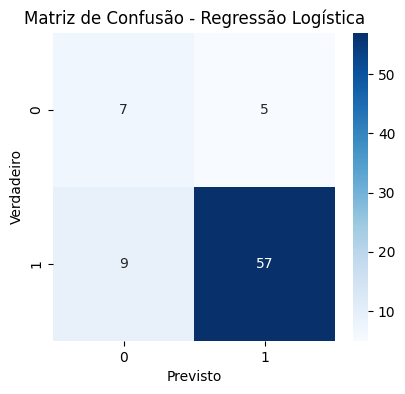

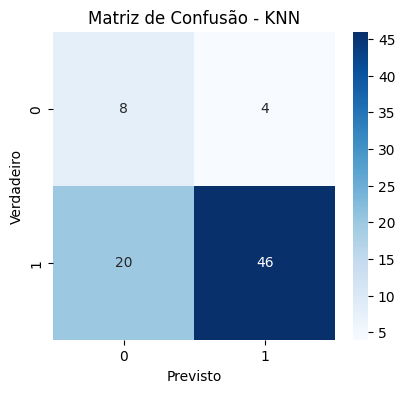

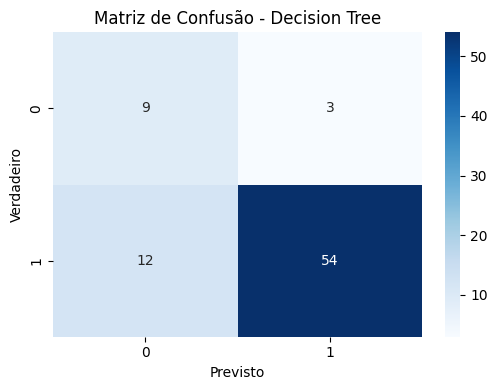

In [ ]:
# Previsões dos modelos
y_pred_log = log_model.predict(X_test_c)
y_pred_knn = knn_model.predict(X_test_c)
y_clf_dt = dt_model.predict(X_test_c)

# Matriz de confusão

# Gerar matriz de confusão para Regressão Logística
cm_log = confusion_matrix(y_test_c, y_pred_log)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Regressão Logística')
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')

# Gerar matriz de confusão para KNN
cm_knn = confusion_matrix(y_test_c, y_pred_knn)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 2)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - KNN')
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')

# Gerar matriz de confusão para Decision Tree
cm_dt = confusion_matrix(y_test_c, y_clf_dt)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Decision Tree')
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')

plt.tight_layout()
plt.show()

# 📊 Análise de Modelos de Classificação

Este estudo compara o desempenho de três modelos de machine learning:

- Regressão Logística  
- K-Nearest Neighbors (KNN)  
- Decision Tree  

A avaliação foi realizada utilizando **matrizes de confusão**, considerando a previsão da variável **Output (Yes/No)**.

---

# 🔎 1. Regressão Logística

## Matriz de Confusão


## Interpretação

- Verdadeiros Negativos (TN): 7  
- Falsos Positivos (FP): 5  
- Falsos Negativos (FN): 9  
- Verdadeiros Positivos (TP): 57  

## Análise

- O modelo apresentou **bom desempenho geral**
- Conseguiu melhorar a previsão da classe 0
- Manteve alta performance na classe 1
- Ainda possui alguns falsos negativos

✔ Modelo equilibrado e confiável

---

# 🔎 2. K-Nearest Neighbors (KNN)

## Matriz de Confusão


## Interpretação

- Verdadeiros Negativos (TN): 8  
- Falsos Positivos (FP): 4  
- Falsos Negativos (FN): 20  
- Verdadeiros Positivos (TP): 46  

## Análise

- Bom desempenho na classe 0
- Alto número de falsos negativos

⚠️ O modelo falha em identificar muitos casos positivos ("Yes")

❌ Menor desempenho geral entre os modelos

---

# 🔎 3. Decision Tree

## Matriz de Confusão


## Interpretação

- Verdadeiros Negativos (TN): 9  
- Falsos Positivos (FP): 3  
- Falsos Negativos (FN): 12  
- Verdadeiros Positivos (TP): 54  

## Análise

- Melhor desempenho na classe 0
- Menor número de falsos positivos
- Bom equilíbrio entre as classes

✔ Modelo mais consistente

---

# 🏆 Comparação Geral

| Modelo               | Classe 0 | Classe 1 | Equilíbrio |
|--------------------|--------|--------|----------|
| Regressão Logística | Médio  | Excelente | Muito bom |
| KNN                 | Bom    | Ruim      | Fraco     |
| Decision Tree       | Melhor | Muito bom | Melhor    |

---

# 📌 Conclusão

- 🥇 **Decision Tree**: melhor modelo geral, com maior equilíbrio e menor número de erros críticos  
- 🥈 **Regressão Logística**: desempenho muito bom, especialmente na classe positiva  
- 🥉 **KNN**: desempenho inferior, com muitos falsos negativos  

---

# 🚀 Considerações Finais

A escolha do modelo depende do objetivo:

- Se o foco for **detectar mais casos positivos (Yes)** → Regressão Logística  
- Se o foco for **equilíbrio geral** → Decision Tree  

---

# 🔧 Possíveis Melhorias

- Ajuste de hiperparâmetros (Optuna)  


---

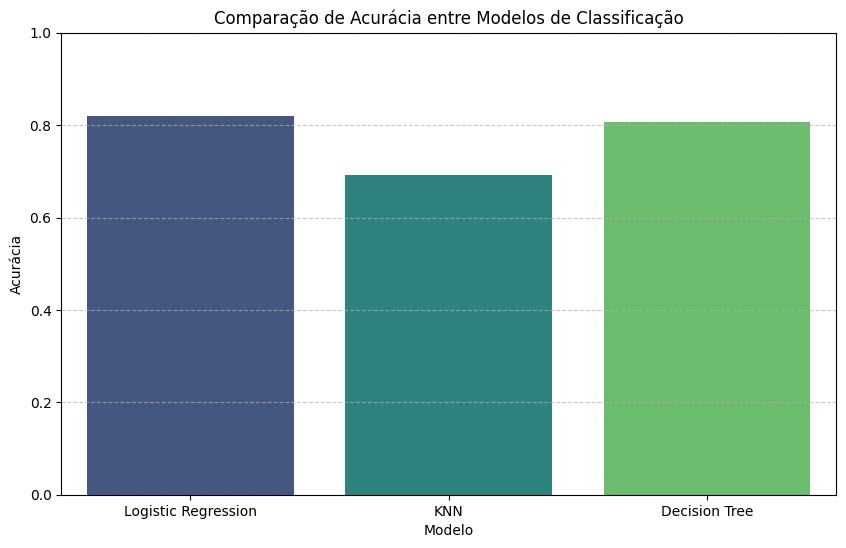

In [ ]:
models = ['Logistic Regression', 'KNN', 'Decision Tree']
accuracies = [accuracy_score(y_test_c, log_model.predict(X_test_c)),
              accuracy_score(y_test_c, knn_model.predict(X_test_c)),
              accuracy_score(y_test_c, dt_model.predict(X_test_c))]

accuracy_df = pd.DataFrame({"Model": models, "Accuracy": accuracies})

plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="Accuracy", hue="Model", data=accuracy_df, palette="viridis", legend=False)
plt.title('Comparação de Acurácia entre Modelos de Classificação')
plt.ylabel('Acurácia')
plt.xlabel('Modelo')
plt.ylim(0, 1) # Acurácia varia de 0 a 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Otimização de modelos com Optuna

In [ ]:
# --- Optuna for Logistic Regression ---
def objective_lr(trial):
    # Define hyperparameters to tune for Logistic Regression
    C = trial.suggest_float('C', 1e-10, 1e10, log=True)
    solver = trial.suggest_categorical('solver', ['liblinear', 'lbfgs', 'sag', 'saga'])

    # Create and train the model
    model = LogisticRegression(C=C, solver=solver, random_state=42, max_iter=1000)
    model.fit(X_train_c, y_train_c)

    # Evaluate the model
    y_pred = model.predict(X_test_c)
    accuracy = accuracy_score(y_test_c, y_pred)

    return accuracy

# Create an Optuna study for Logistic Regression
study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=100) # Run 50 trials

print("\n--- Optuna Results for Logistic Regression ---")
print(f"Number of finished trials: {len(study_lr.trials)}")
print(f"Best trial: {study_lr.best_trial.value:.4f} (Accuracy)")
print("Best hyperparameters: ", study_lr.best_trial.params)

# Train Logistic Regression with best parameters
best_lr_model = LogisticRegression(**study_lr.best_trial.params, random_state=42, max_iter=1000)
best_lr_model.fit(X_train_c, y_train_c)

# Evaluate best LR model
y_pred_best_lr = best_lr_model.predict(X_test_c)
accuracy_best_lr = accuracy_score(y_test_c, y_pred_best_lr)

print(f"Accuracy of Best Logistic Regression (Optuna): {accuracy_best_lr:.2f}")
print("Classification Report (Best Logistic Regression):\n", classification_report(y_test_c, y_pred_best_lr))

[I 2026-03-21 21:09:22,369] A new study created in memory with name: no-name-fda32d7b-0dd6-4bad-94c9-87f2f5676ce5
[I 2026-03-21 21:09:22,379] Trial 0 finished with value: 0.7307692307692307 and parameters: {'C': 3.269487923039301e-06, 'solver': 'liblinear'}. Best is trial 0 with value: 0.7307692307692307.
[I 2026-03-21 21:09:22,389] Trial 1 finished with value: 0.8461538461538461 and parameters: {'C': 4.799937743454226e-07, 'solver': 'lbfgs'}. Best is trial 1 with value: 0.8461538461538461.
[I 2026-03-21 21:09:22,414] Trial 2 finished with value: 0.8333333333333334 and parameters: {'C': 956.3993685361011, 'solver': 'sag'}. Best is trial 1 with value: 0.8461538461538461.
[I 2026-03-21 21:09:22,424] Trial 3 finished with value: 0.8333333333333334 and parameters: {'C': 3959.3034423603117, 'solver': 'lbfgs'}. Best is trial 1 with value: 0.8461538461538461.
[I 2026-03-21 21:09:22,432] Trial 4 finished with value: 0.8461538461538461 and parameters: {'C': 6.667464303170761e-05, 'solver': 'lbf


--- Optuna Results for Logistic Regression ---
Number of finished trials: 100
Best trial: 0.8718 (Accuracy)
Best hyperparameters:  {'C': 0.06791864592854079, 'solver': 'lbfgs'}
Accuracy of Best Logistic Regression (Optuna): 0.87
Classification Report (Best Logistic Regression):
               precision    recall  f1-score   support

           0       1.00      0.17      0.29        12
           1       0.87      1.00      0.93        66

    accuracy                           0.87        78
   macro avg       0.93      0.58      0.61        78
weighted avg       0.89      0.87      0.83        78



In [ ]:
# --- Optuna for KNN ---
def objective_knn(trial):
    # Define hyperparameters to tune for KNN
    n_neighbors = trial.suggest_int('n_neighbors', 1, 30) # Number of neighbors
    weights = trial.suggest_categorical('weights', ['uniform', 'distance']) # Weight function
    metric = trial.suggest_categorical('metric', ['euclidean', 'manhattan', 'minkowski'])

    # Create and train the model
    model = KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights, metric=metric)
    model.fit(X_train_c, y_train_c)

    # Evaluate the model
    y_pred = model.predict(X_test_c)
    accuracy = accuracy_score(y_test_c, y_pred)

    return accuracy

# Create an Optuna study for KNN
study_knn = optuna.create_study(direction='maximize')
study_knn.optimize(objective_knn, n_trials=100) # Run 50 trials

print("\n--- Optuna Results for KNN ---")
print(f"Number of finished trials: {len(study_knn.trials)}")
print(f"Best trial: {study_knn.best_trial.value:.4f} (Accuracy)")
print("Best hyperparameters: ", study_knn.best_trial.params)

# Train KNN with best parameters
best_knn_model = KNeighborsClassifier(**study_knn.best_trial.params)
best_knn_model.fit(X_train_c, y_train_c)

# Evaluate best KNN model
y_pred_best_knn = best_knn_model.predict(X_test_c)
accuracy_best_knn = accuracy_score(y_test_c, y_pred_best_knn)

print(f"Accuracy of Best KNN (Optuna): {accuracy_best_knn:.2f}")
print("Classification Report (Best KNN):\n", classification_report(y_test_c, y_pred_best_knn))

[I 2026-03-21 21:09:25,128] A new study created in memory with name: no-name-e165d9f1-bd98-45e4-b520-1affeb128e61
[I 2026-03-21 21:09:25,139] Trial 0 finished with value: 0.8076923076923077 and parameters: {'n_neighbors': 10, 'weights': 'uniform', 'metric': 'minkowski'}. Best is trial 0 with value: 0.8076923076923077.
[I 2026-03-21 21:09:25,148] Trial 1 finished with value: 0.8205128205128205 and parameters: {'n_neighbors': 5, 'weights': 'uniform', 'metric': 'manhattan'}. Best is trial 1 with value: 0.8205128205128205.
[I 2026-03-21 21:09:25,156] Trial 2 finished with value: 0.8205128205128205 and parameters: {'n_neighbors': 29, 'weights': 'distance', 'metric': 'euclidean'}. Best is trial 1 with value: 0.8205128205128205.
[I 2026-03-21 21:09:25,167] Trial 3 finished with value: 0.8205128205128205 and parameters: {'n_neighbors': 24, 'weights': 'distance', 'metric': 'euclidean'}. Best is trial 1 with value: 0.8205128205128205.
[I 2026-03-21 21:09:25,178] Trial 4 finished with value: 0.83


--- Optuna Results for KNN ---
Number of finished trials: 100
Best trial: 0.8846 (Accuracy)
Best hyperparameters:  {'n_neighbors': 19, 'weights': 'uniform', 'metric': 'minkowski'}
Accuracy of Best KNN (Optuna): 0.88
Classification Report (Best KNN):
               precision    recall  f1-score   support

           0       1.00      0.25      0.40        12
           1       0.88      1.00      0.94        66

    accuracy                           0.88        78
   macro avg       0.94      0.62      0.67        78
weighted avg       0.90      0.88      0.85        78



In [ ]:
# --- Optuna for Decision Tree ---
def objective_dt(trial):
    # Define hyperparameters to tune for Decision Tree
    max_depth = trial.suggest_int('max_depth', 1, 32)
    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])
    splitter = trial.suggest_categorical('splitter', ['best', 'random'])

    # Create and train the model
    model = DecisionTreeClassifier(max_depth=max_depth, criterion=criterion, splitter=splitter, random_state=42)
    model.fit(X_train_c, y_train_c)

    # Evaluate the model
    y_pred = model.predict(X_test_c)
    accuracy = accuracy_score(y_test_c, y_pred)

    return accuracy

# Create an Optuna study for Decision Tree
study_dt = optuna.create_study(direction='maximize')
study_dt.optimize(objective_dt, n_trials=100) # Run 100 trials

print("\n--- Optuna Results for Decision Tree ---")
print(f"Number of finished trials: {len(study_dt.trials)}")
print(f"Best trial: {study_dt.best_trial.value:.4f} (Accuracy)")
print("Best hyperparameters: ", study_dt.best_trial.params)

# Train Decision Tree with best parameters
best_dt_model = DecisionTreeClassifier(**study_dt.best_trial.params, random_state=42)
best_dt_model.fit(X_train_c, y_train_c)

# Evaluate best DT model
y_pred_best_dt = best_dt_model.predict(X_test_c)
accuracy_best_dt = accuracy_score(y_test_c, y_pred_best_dt)

print(f"Accuracy of Best Decision Tree (Optuna): {accuracy_best_dt:.2f}")
print("Classification Report (Best Decision Tree):\n", classification_report(y_test_c, y_pred_best_dt))

[I 2026-03-21 21:09:26,581] A new study created in memory with name: no-name-8e6407ba-8fa8-4b7d-8268-0c5b9cf9fe15
[I 2026-03-21 21:09:26,591] Trial 0 finished with value: 0.7948717948717948 and parameters: {'max_depth': 4, 'criterion': 'gini', 'splitter': 'best'}. Best is trial 0 with value: 0.7948717948717948.
[I 2026-03-21 21:09:26,600] Trial 1 finished with value: 0.8333333333333334 and parameters: {'max_depth': 10, 'criterion': 'entropy', 'splitter': 'best'}. Best is trial 1 with value: 0.8333333333333334.
[I 2026-03-21 21:09:26,609] Trial 2 finished with value: 0.782051282051282 and parameters: {'max_depth': 32, 'criterion': 'gini', 'splitter': 'random'}. Best is trial 1 with value: 0.8333333333333334.
[I 2026-03-21 21:09:26,618] Trial 3 finished with value: 0.8333333333333334 and parameters: {'max_depth': 3, 'criterion': 'entropy', 'splitter': 'random'}. Best is trial 1 with value: 0.8333333333333334.
[I 2026-03-21 21:09:26,629] Trial 4 finished with value: 0.8589743589743589 and


--- Optuna Results for Decision Tree ---
Number of finished trials: 100
Best trial: 0.9103 (Accuracy)
Best hyperparameters:  {'max_depth': 9, 'criterion': 'entropy', 'splitter': 'random'}
Accuracy of Best Decision Tree (Optuna): 0.91
Classification Report (Best Decision Tree):
               precision    recall  f1-score   support

           0       0.73      0.67      0.70        12
           1       0.94      0.95      0.95        66

    accuracy                           0.91        78
   macro avg       0.83      0.81      0.82        78
weighted avg       0.91      0.91      0.91        78



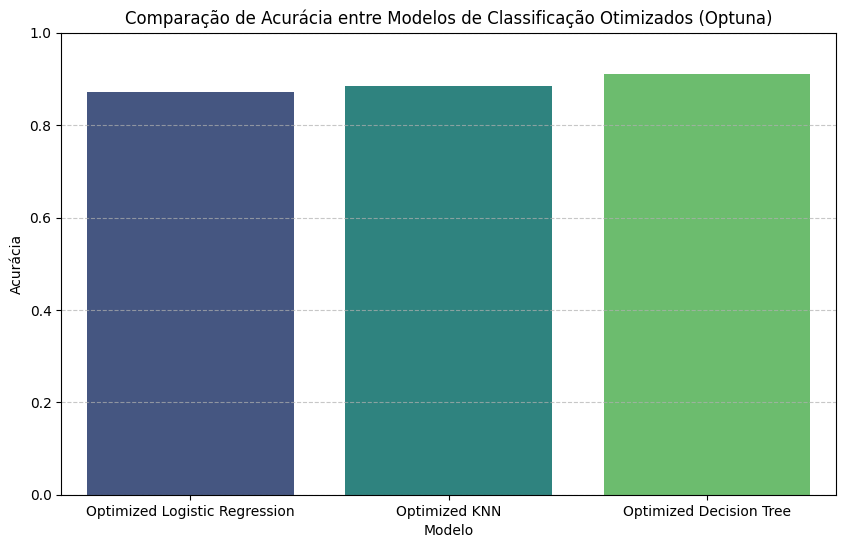

In [ ]:
optimized_models = ['Optimized Logistic Regression', 'Optimized KNN', 'Optimized Decision Tree']
optimized_accuracies = [accuracy_best_lr,
                        accuracy_best_knn,
                        accuracy_best_dt]

optimized_accuracy_df = pd.DataFrame({"Model": optimized_models, "Accuracy": optimized_accuracies})

plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="Accuracy", hue="Model", data=optimized_accuracy_df, palette="viridis", legend=False)
plt.title('Comparação de Acurácia entre Modelos de Classificação Otimizados (Optuna)')
plt.ylabel('Acurácia')
plt.xlabel('Modelo')
plt.ylim(0, 1) # Acurácia varia de 0 a 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

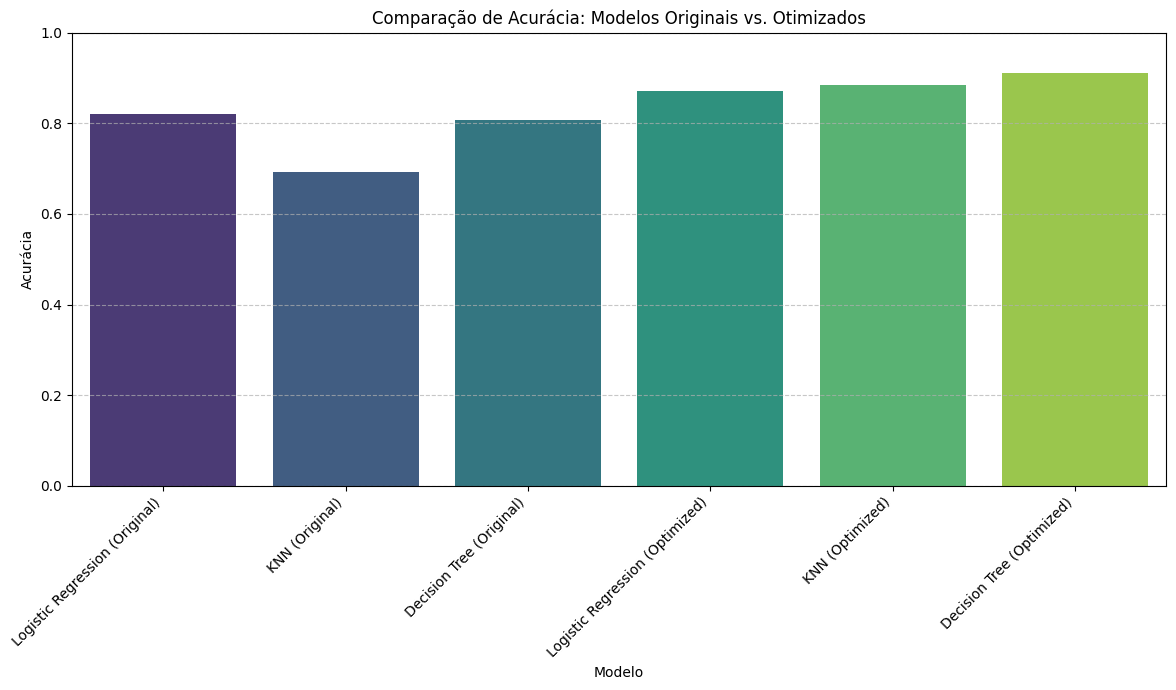

In [ ]:
comparison_data = {
    'Model': ['Logistic Regression (Original)', 'KNN (Original)', 'Decision Tree (Original)',
              'Logistic Regression (Optimized)', 'KNN (Optimized)', 'Decision Tree (Optimized)'],
    'Accuracy': [accuracies[0], accuracies[1], accuracies[2],
                 accuracy_best_lr, accuracy_best_knn, accuracy_best_dt]
}

comparison_df = pd.DataFrame(comparison_data)

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Accuracy', hue='Model', data=comparison_df, palette='viridis', legend=False)
plt.title('Comparação de Acurácia: Modelos Originais vs. Otimizados')
plt.ylabel('Acurácia')
plt.xlabel('Modelo')
plt.ylim(0, 1) # Acurácia varia de 0 a 1
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Previsões dos modelos otimizados
y_pred_best_log = best_lr_model.predict(X_test_c)
y_pred_best_knn = best_knn_model.predict(X_test_c)
y_pred_best_dt = best_dt_model.predict(X_test_c)



# Matriz de Confusão para Regressão Logística Otimizada
cm_best_log = confusion_matrix(y_test_c, y_pred_best_log) # Corrigido: y_pred_best_log



# Matriz de Confusão para KNN Otimizado
cm_best_knn = confusion_matrix(y_test_c, y_pred_best_knn)



# Matriz de Confusão para Decision Tree Otimizada
cm_best_dt = confusion_matrix(y_test_c, y_pred_best_dt)





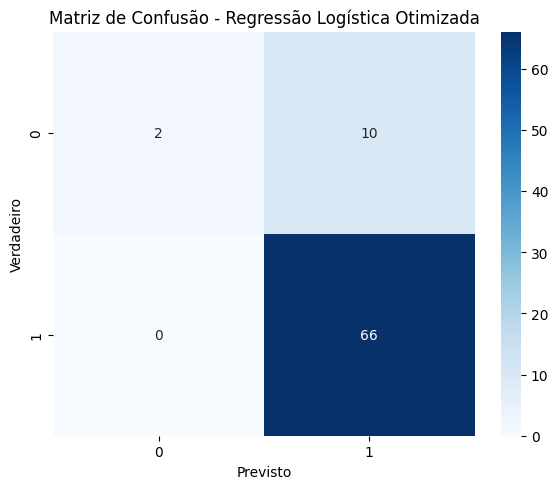

In [ ]:
# Matriz de Confusão para Regressão Logística Otimizada
plt.figure(figsize=(6, 5))
sns.heatmap(cm_best_log, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Regressão Logística Otimizada')
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.tight_layout()
plt.show()

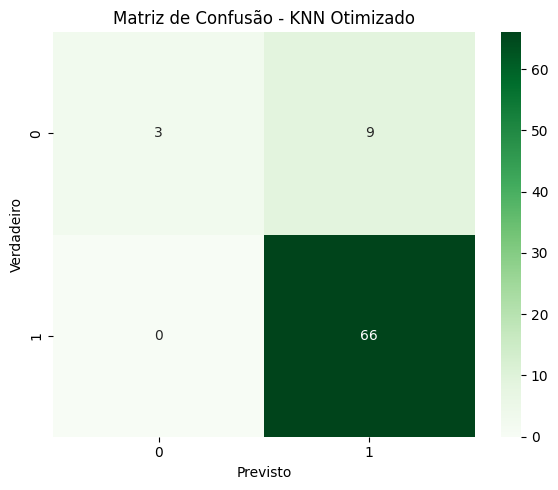

In [ ]:
# Matriz de Confusão para KNN Otimizado
plt.figure(figsize=(6, 5))
sns.heatmap(cm_best_knn, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusão - KNN Otimizado')
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.tight_layout()
plt.show()

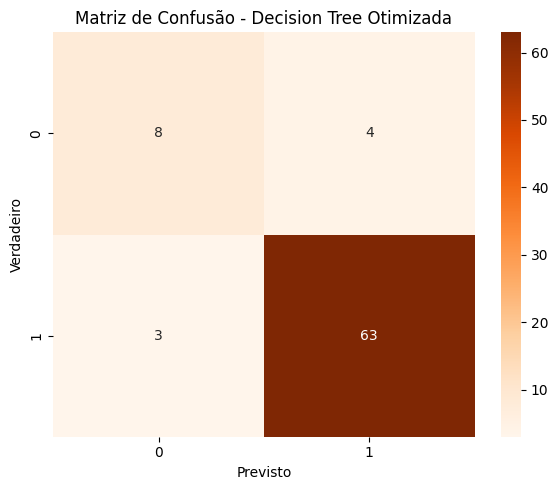

In [ ]:
# Matriz de Confusão para Decision Tree Otimizada
plt.figure(figsize=(6, 5))
sns.heatmap(cm_best_dt, annot=True, fmt='d', cmap='Oranges')
plt.title('Matriz de Confusão - Decision Tree Otimizada')
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.tight_layout()
plt.show()

# 📊 Comparação entre Modelos de Classificação (Após Otimização com Optuna)

A comparação entre os modelos de classificação antes e depois da otimização evidencia o impacto significativo do ajuste de hiperparâmetros utilizando o **Optuna**. Foram avaliados três algoritmos: Regressão Logística, KNN e Árvore de Decisão.

---

## 🔎 Regressão Logística (Logistic Regression)

O modelo de Regressão Logística otimizado alcançou uma **acurácia de 0.87**, com os seguintes hiperparâmetros ideais:

- `C = 0.0679`
- `solver = lbfgs`

### 📈 Análise dos resultados:

- **Precision (classe 0 - Não):** 1.00  
- **Recall (classe 0 - Não):** 0.17  
- **F1-score (classe 0):** 0.29  

### 🧠 Interpretação:

- O modelo acerta quando prevê "Não" (alta precisão)
- Porém **falha em identificar muitos casos dessa classe** (baixo recall)

📌 **Conclusão:**  
O modelo apresenta bom desempenho global, mas ainda sofre com o desbalanceamento, tendo dificuldade em reconhecer a classe minoritária.

---

## 🔎 KNN (K-Nearest Neighbors)

O modelo KNN otimizado apresentou uma **acurácia de 0.88**, com os seguintes hiperparâmetros:

- `n_neighbors = 19`
- `weights = uniform`
- `metric = minkowski`

### 📈 Análise dos resultados:

- **Precision (classe 0):** 1.00  
- **Recall (classe 0):** 0.25  
- **F1-score (classe 0):** 0.40  

### 🧠 Interpretação:

- Apresenta leve melhora na identificação da classe 0
- Ainda possui dificuldade em capturar todos os casos negativos

📌 **Conclusão:**  
O KNN manteve um desempenho estável e ligeiramente superior à Regressão Logística, mas ainda apresenta limitações na classe minoritária.

---

## 🔎 Árvore de Decisão (Decision Tree)

A Árvore de Decisão foi o modelo com melhor desempenho após otimização, alcançando uma **acurácia de 0.91**, com os seguintes parâmetros:

- `max_depth = 9`
- `criterion = entropy`
- `splitter = random`

### 📈 Análise dos resultados:

- **Precision (classe 0):** 0.73  
- **Recall (classe 0):** 0.67  
- **F1-score (classe 0):** 0.70  

### 🧠 Interpretação:

- Melhor capacidade de identificar a classe minoritária
- Mantém alto desempenho na classe majoritária
- Apresenta equilíbrio entre precisão e recall

📌 **Conclusão:**  
A Árvore de Decisão apresentou o melhor equilíbrio entre as classes, com desempenho consistente e maior capacidade de generalização.

---

# 🏆 Conclusão Geral

O uso do **Optuna** foi altamente eficaz, resultando em melhorias claras no desempenho dos modelos.

### 📊 Comparação final:

| Modelo               | Acurácia | Recall Classe 0 | Destaque |
|--------------------|---------|----------------|---------|
| Decision Tree       | **0.91** | **0.67**       | Melhor equilíbrio |
| KNN                 | 0.88    | 0.25           | Desempenho estável |
| Regressão Logística | 0.87    | 0.17           | Alta precisão |

---

## ⚠️ Insight importante

Mesmo com alta acurácia, os modelos ainda demonstram impacto do **desbalanceamento de classes**, especialmente:

- Baixo recall da classe 0 nos modelos Logístico e KNN

---

## 🚀 Considerações Finais

A escolha do melhor modelo deve considerar não apenas a acurácia, mas também:

- Precisão (Precision)  
- Recall  
- F1-score  
- Equilíbrio entre classes  

📌 Nesse cenário, a **Árvore de Decisão otimizada** se destaca como a melhor opção, por apresentar o melhor equilíbrio entre desempenho geral e capacidade de identificar ambas as classes.

# MODELO DE REGRESSÃO

# 1 - Coleta/seleção do dataset

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import os



dfre = pd.read_csv("/content/train_energy_data.csv")


In [ ]:

dfre

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17
...,...,...,...,...,...,...,...
995,Residential,14419,68,44,23.95,Weekend,3661.21
996,Industrial,12194,7,22,14.67,Weekend,3546.34
997,Commercial,39562,88,20,32.18,Weekday,5147.21
998,Residential,8348,67,37,16.48,Weekend,3244.98


# 2 - Preparação dos dados

In [ ]:

dfre.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        1000 non-null   object 
 1   Square Footage       1000 non-null   int64  
 2   Number of Occupants  1000 non-null   int64  
 3   Appliances Used      1000 non-null   int64  
 4   Average Temperature  1000 non-null   float64
 5   Day of Week          1000 non-null   object 
 6   Energy Consumption   1000 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 54.8+ KB


In [ ]:
# Make a copy to avoid modifying the original dfre directly and to incorporate changes
dfre_temp = dfre.copy()

# Initialize LabelEncoder
le_building_type = LabelEncoder()

# Encode 'Building Type' column, LabelEncoder by default outputs integers
dfre_temp['Building Type'] = le_building_type.fit_transform(dfre_temp['Building Type'])

# Update dfres to include the encoded 'Building Type' and drop 'Day of Week'
dfres = dfre_temp.drop(['Day of Week'], axis=1)

print("Coluna 'Building Type' convertida para numérico (inteiro) usando LabelEncoder.")
print("DataFrame 'dfres' atualizado. As colunas agora são:")
dfres.columns
print("\nInformações do DataFrame 'dfres' (dtypes):")
dfres.info()
print("\nPrimeiras 5 linhas de 'dfres' com 'Building Type' codificado:")
dfres.head()

Coluna 'Building Type' convertida para numérico (inteiro) usando LabelEncoder.
DataFrame 'dfres' atualizado. As colunas agora são:

Informações do DataFrame 'dfres' (dtypes):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        1000 non-null   int64  
 1   Square Footage       1000 non-null   int64  
 2   Number of Occupants  1000 non-null   int64  
 3   Appliances Used      1000 non-null   int64  
 4   Average Temperature  1000 non-null   float64
 5   Energy Consumption   1000 non-null   float64
dtypes: float64(2), int64(4)
memory usage: 47.0 KB

Primeiras 5 linhas de 'dfres' com 'Building Type' codificado:


,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
0,2,7063,76,10,29.84,2713.95
1,0,44372,66,45,16.72,5744.99
2,1,19255,37,17,14.30,4101.24
3,2,13265,14,41,32.82,3009.14
4,0,13375,26,18,11.92,3279.17


# 3 - Divisão em conjunto de treino e teste


In [ ]:
# Seleção de Features (X) e Target (y)

X = dfres.drop(columns=['Energy Consumption']) # Tudo exceto o que queremos prever
y = dfres['Energy Consumption'] # O alvo


#  Divisão Treino/Teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Divisão Treino/Teste")

Divisão Treino/Teste


# 4 - Treinamento do modelo

In [ ]:
# Treinamento LinearRegression
modelre = LinearRegression()
modelre.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Treinamento RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
# Treinamento XGBRegressor
xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

# 5 - Avaliação do modelo

In [ ]:
# Previsões
y_pred = modelre.predict(X_test)

# Métricas
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"--- Resultados do Modelo LinearRegression ---")
print(f"MAE: {mae:.2f} ")
print(f"RMSE: {rmse:.2f} ")
print(f"R² Score: {r2:.4f}")

--- Resultados do Modelo LinearRegression ---
MAE: 330.67 kWh
RMSE: 355.76 kWh
R² Score: 0.8446


In [ ]:
# Previsões
y_pred_rf = rf_model.predict(X_test)

# Métricas
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("--- Resultados do Modelo Random Forest ---")
print(f"MAE (Random Forest): {mae_rf:.2f} ")
print(f"RMSE (Random Forest): {rmse_rf:.2f} ")
print(f"R² Score (Random Forest): {r2_rf:.4f}")

--- Resultados do Modelo Random Forest ---
MAE (Random Forest): 109.46 kWh
RMSE (Random Forest): 134.80 kWh
R² Score (Random Forest): 0.9777


In [ ]:
# Previsões
y_pred_xgb = xgb_model.predict(X_test)

# Métricas
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("\n--- Resultados do Modelo XGBoost ---")
print(f"MAE (XGBoost): {mae_xgb:.2f} ")
print(f"RMSE (XGBoost): {rmse_xgb:.2f} ")
print(f"R² Score (XGBoost): {r2_xgb:.4f}")


--- Resultados do Modelo XGBoost ---
MAE (XGBoost): 112.67 kWh
RMSE (XGBoost): 137.56 kWh
R² Score (XGBoost): 0.9768


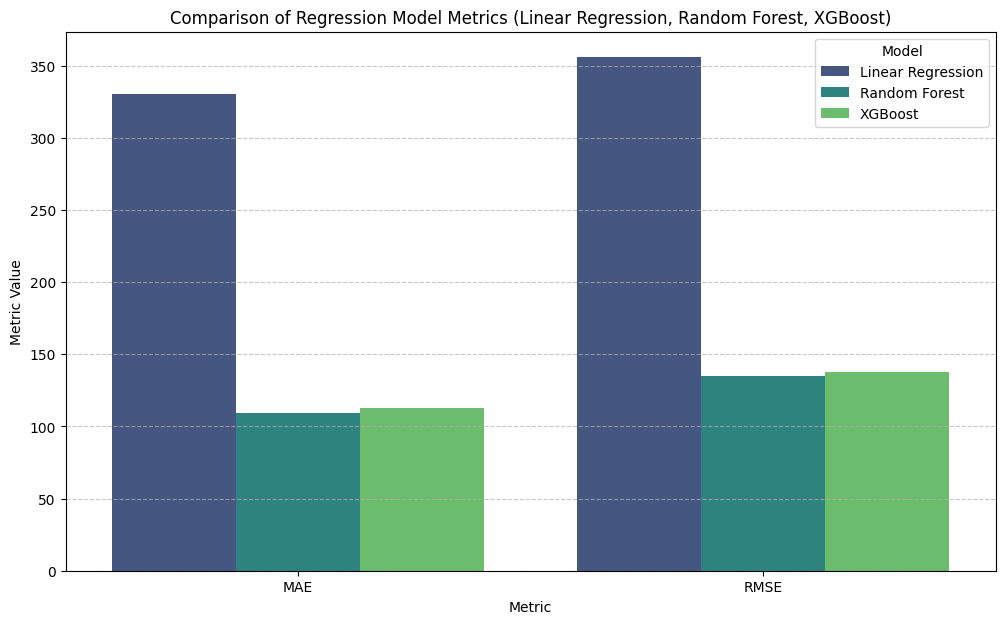

In [ ]:
metrics_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost', 'Linear Regression', 'Random Forest', 'XGBoost'],
    'Metric': ['MAE', 'MAE', 'MAE', 'RMSE', 'RMSE', 'RMSE'],
    'Value': [mae, mae_rf, mae_xgb, rmse, rmse_rf, rmse_xgb]
})

plt.figure(figsize=(12, 7))
sns.barplot(x='Metric', y='Value', hue='Model', data=metrics_df, palette='viridis')
plt.title('Comparison of Regression Model Metrics (Linear Regression, Random Forest, XGBoost)')
plt.ylabel('Metric Value')
plt.xlabel('Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

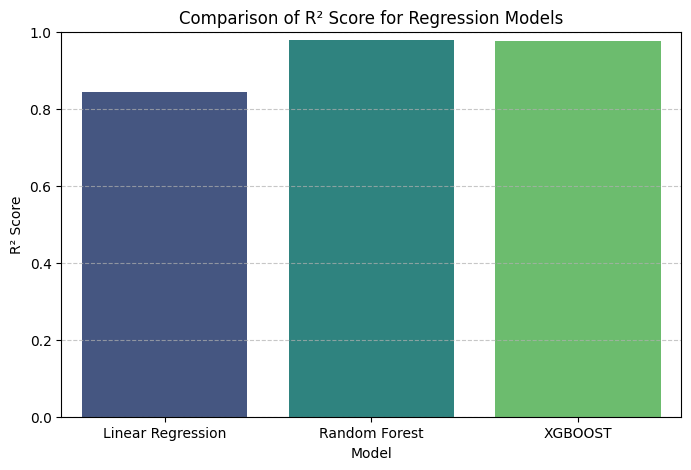

In [ ]:
r2_comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest','XGBOOST'],
    'R2 Score': [r2, r2_rf,r2_xgb]
})

plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='R2 Score', data=r2_comparison_df, hue='Model', palette='viridis', legend=False)
plt.title('Comparison of R² Score for Regression Models')
plt.ylabel('R² Score')
plt.xlabel('Model')
plt.ylim(0, 1) # R2 score is typically between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Comparação entre os Modelos de Regressão

Aqui está a comparação dos modelos de regressão, focando nas métricas de avaliação:

### Regressão Linear:
**R² Score:** 0.8446
**MAE:** 330.67 kWh
**RMSE:** 355.76 kWh

**Relatório Detalhado:** A Regressão Linear apresentou um bom R² de 0.8446, o que significa que ela conseguiu explicar cerca de 84.46% da variância no consumo de energia. No entanto, os valores de MAE (330.67 kWh) e RMSE (355.76 kWh) são relativamente altos, indicando que as previsões do modelo têm um desvio médio considerável dos valores reais. Isso sugere que o modelo linear pode não estar capturando todas as complexidades dos dados.

### Random Forest Regressor:
**R² Score:** 0.9777
**MAE:** 109.46 kWh
**RMSE:** 134.80 kWh

**Relatório Detalhado:** O modelo Random Forest demonstrou um desempenho excelente. Com um R² de 0.9777, ele explica quase 97.77% da variância, indicando um ajuste muito forte aos dados. Seus valores de MAE (109.46 kWh) e RMSE (134.80 kWh) são significativamente menores do que os da Regressão Linear, mostrando que este modelo faz previsões muito mais precisas e com menor erro médio. O Random Forest é capaz de modelar relações não lineares e interações complexas nos dados, o que provavelmente contribuiu para seu desempenho superior.

### XGBoost Regressor:
**R² Score:** 0.9768
**MAE:** 112.67 kWh
**RMSE:** 137.56 kWh

**Relatório Detalhado:** O XGBoost também apresentou um desempenho excepcional, muito próximo ao do Random Forest. Seu R² de 0.9768 é quase idêntico ao do Random Forest, e seus MAE (112.67 kWh) e RMSE (137.56 kWh) são ligeiramente superiores, mas ainda muito baixos em comparação com a Regressão Linear. O XGBoost é conhecido por sua capacidade de lidar com dados complexos e sua robustez, sendo uma excelente escolha para problemas de regressão.

### Conclusão dos Modelos de Regressão:

Os modelos baseados em árvores, **Random Forest** e **XGBoost**, superaram a **Regressão Linear** por uma margem considerável em todas as métricas de desempenho. Ambos os modelos Random Forest e XGBoost foram extremamente eficazes na previsão do consumo de energia, com R² scores acima de 0.97 e erros médios muito baixos.

Entre os três, o **Random Forest** apresentou o melhor desempenho geral, com o menor MAE e RMSE e o maior R² Score, indicando que ele foi o mais preciso na previsão do consumo de energia para este conjunto de dados. Isso sugere que as relações entre as características e o consumo de energia são complexas e não-lineares, sendo melhor capturadas por algoritmos mais sofisticados como os de ensemble.

## Otimização de modelos com Optuna

In [ ]:
import optuna
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

# --- Optuna for Linear Regression (Although it has few hyperparameters, it's good for consistency) ---
def objective_lr_reg(trial):
    # Linear Regression has very few hyperparameters to tune. We can tune 'fit_intercept'.
    fit_intercept = trial.suggest_categorical('fit_intercept', [True, False])

    model = LinearRegression(fit_intercept=fit_intercept)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    return rmse

print("Iniciando Optuna para Linear Regression...")
study_lr_reg = optuna.create_study(direction='minimize')
study_lr_reg.optimize(objective_lr_reg, n_trials=100) # Fewer trials as less to tune

print("\n--- Optuna Resultados para Linear Regression ---")
print(f"Number of finished trials: {len(study_lr_reg.trials)}")
print(f"Best trial RMSE: {study_lr_reg.best_trial.value:.2f}")
print("Best hyperparameters: ", study_lr_reg.best_trial.params)

best_lr_reg_model = LinearRegression(**study_lr_reg.best_trial.params)
best_lr_reg_model.fit(X_train, y_train)
y_pred_best_lr_reg = best_lr_reg_model.predict(X_test)
rmse_best_lr_reg = np.sqrt(mean_squared_error(y_test, y_pred_best_lr_reg))
r2_best_lr_reg = r2_score(y_test, y_pred_best_lr_reg)
print(f"RMSE of Best Linear Regression (Optuna): {rmse_best_lr_reg:.2f}")
print(f"R2 Score of Best Linear Regression (Optuna): {r2_best_lr_reg:.4f}")








[I 2026-03-21 21:09:32,550] A new study created in memory with name: no-name-9174a09b-d442-4fc9-98ad-7b39953f6603
[I 2026-03-21 21:09:32,575] Trial 0 finished with value: 595.4222997126886 and parameters: {'fit_intercept': False}. Best is trial 0 with value: 595.4222997126886.
[I 2026-03-21 21:09:32,600] Trial 1 finished with value: 595.4222997126886 and parameters: {'fit_intercept': False}. Best is trial 0 with value: 595.4222997126886.
[I 2026-03-21 21:09:32,612] Trial 2 finished with value: 595.4222997126886 and parameters: {'fit_intercept': False}. Best is trial 0 with value: 595.4222997126886.
[I 2026-03-21 21:09:32,622] Trial 3 finished with value: 595.4222997126886 and parameters: {'fit_intercept': False}. Best is trial 0 with value: 595.4222997126886.
[I 2026-03-21 21:09:32,639] Trial 4 finished with value: 355.7558296066516 and parameters: {'fit_intercept': True}. Best is trial 4 with value: 355.7558296066516.
[I 2026-03-21 21:09:32,651] Trial 5 finished with value: 595.422299

Iniciando Optuna para Linear Regression...


[I 2026-03-21 21:09:32,763] Trial 13 finished with value: 355.7558296066516 and parameters: {'fit_intercept': True}. Best is trial 4 with value: 355.7558296066516.
[I 2026-03-21 21:09:32,786] Trial 14 finished with value: 355.7558296066516 and parameters: {'fit_intercept': True}. Best is trial 4 with value: 355.7558296066516.
[I 2026-03-21 21:09:32,832] Trial 15 finished with value: 355.7558296066516 and parameters: {'fit_intercept': True}. Best is trial 4 with value: 355.7558296066516.
[I 2026-03-21 21:09:32,847] Trial 16 finished with value: 355.7558296066516 and parameters: {'fit_intercept': True}. Best is trial 4 with value: 355.7558296066516.
[I 2026-03-21 21:09:32,857] Trial 17 finished with value: 355.7558296066516 and parameters: {'fit_intercept': True}. Best is trial 4 with value: 355.7558296066516.
[I 2026-03-21 21:09:32,878] Trial 18 finished with value: 355.7558296066516 and parameters: {'fit_intercept': True}. Best is trial 4 with value: 355.7558296066516.
[I 2026-03-21 21


--- Optuna Resultados para Linear Regression ---
Number of finished trials: 100
Best trial RMSE: 355.76
Best hyperparameters:  {'fit_intercept': True}
RMSE of Best Linear Regression (Optuna): 355.76
R2 Score of Best Linear Regression (Optuna): 0.8446


In [ ]:
# --- Optuna for RandomForestRegressor ---
def objective_rf(trial):
    n_estimators = trial.suggest_int('n_estimators', 10, 200)
    max_depth = trial.suggest_int('max_depth', 2, 32)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
    bootstrap = trial.suggest_categorical('bootstrap', [True, False])

    model = RandomForestRegressor(n_estimators=n_estimators,
                                  max_depth=max_depth,
                                  min_samples_split=min_samples_split,
                                  min_samples_leaf=min_samples_leaf,
                                  bootstrap=bootstrap,
                                  random_state=42,
                                  n_jobs=-1)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    return rmse

print("\nIniciando Optuna para Random Forest Regressor...")
study_rf = optuna.create_study(direction='minimize')
study_rf.optimize(objective_rf, n_trials=100) # Run more trials for complex models

print("\n--- Optuna Resultados Random Forest Regressor ---")
print(f"Number of finished trials: {len(study_rf.trials)}")
print(f"Best trial RMSE: {study_rf.best_trial.value:.2f}")
print("Best hyperparameters: ", study_rf.best_trial.params)

best_rf_model = RandomForestRegressor(**study_rf.best_trial.params, random_state=42, n_jobs=-1)
best_rf_model.fit(X_train, y_train)
y_pred_best_rf = best_rf_model.predict(X_test)
rmse_best_rf = np.sqrt(mean_squared_error(y_test, y_pred_best_rf))
r2_best_rf = r2_score(y_test, y_pred_best_rf)
print(f"RMSE of Best Random Forest (Optuna): {rmse_best_rf:.2f}")
print(f"R2 Score of Best Random Forest (Optuna): {r2_best_rf:.4f}")

[I 2026-03-21 21:09:34,451] A new study created in memory with name: no-name-92bdbc70-1c48-44ac-b542-d241da9e3fca



Iniciando Optuna para Random Forest Regressor...


[I 2026-03-21 21:09:34,912] Trial 0 finished with value: 433.4913969406717 and parameters: {'n_estimators': 78, 'max_depth': 4, 'min_samples_split': 6, 'min_samples_leaf': 9, 'bootstrap': False}. Best is trial 0 with value: 433.4913969406717.
[I 2026-03-21 21:09:35,661] Trial 1 finished with value: 302.4350357161108 and parameters: {'n_estimators': 124, 'max_depth': 17, 'min_samples_split': 9, 'min_samples_leaf': 13, 'bootstrap': False}. Best is trial 1 with value: 302.4350357161108.
[I 2026-03-21 21:09:36,511] Trial 2 finished with value: 240.44840635006807 and parameters: {'n_estimators': 151, 'max_depth': 26, 'min_samples_split': 6, 'min_samples_leaf': 13, 'bootstrap': True}. Best is trial 2 with value: 240.44840635006807.
[I 2026-03-21 21:09:37,306] Trial 3 finished with value: 224.760262804114 and parameters: {'n_estimators': 141, 'max_depth': 12, 'min_samples_split': 7, 'min_samples_leaf': 11, 'bootstrap': True}. Best is trial 3 with value: 224.760262804114.
[I 2026-03-21 21:09:3


--- Optuna Resultados Random Forest Regressor ---
Number of finished trials: 100
Best trial RMSE: 135.54
Best hyperparameters:  {'n_estimators': 94, 'max_depth': 12, 'min_samples_split': 3, 'min_samples_leaf': 1, 'bootstrap': True}
RMSE of Best Random Forest (Optuna): 135.54
R2 Score of Best Random Forest (Optuna): 0.9774


In [ ]:
# --- Optuna for XGBoost Regressor ---
def objective_xgb(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 2, 10)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3)
    subsample = trial.suggest_float('subsample', 0.6, 1.0)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.6, 1.0)
    gamma = trial.suggest_float('gamma', 0.0, 0.5)

    model = xgb.XGBRegressor(objective='reg:squarederror',
                             n_estimators=n_estimators,
                             max_depth=max_depth,
                             learning_rate=learning_rate,
                             subsample=subsample,
                             colsample_bytree=colsample_bytree,
                             gamma=gamma,
                             random_state=42,
                             n_jobs=-1)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    return rmse

print("\nIniciando Optuna para XGBoost Regressor...")
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=100) # Run more trials for complex models

print("\n--- Optuna Resultados para XGBoost Regressor ---")
print(f"Number of finished trials: {len(study_xgb.trials)}")
print(f"Best trial RMSE: {study_xgb.best_trial.value:.2f}")
print("Best hyperparameters: ", study_xgb.best_trial.params)

best_xgb_model = xgb.XGBRegressor(objective='reg:squarederror', **study_xgb.best_trial.params, random_state=42, n_jobs=-1)
best_xgb_model.fit(X_train, y_train)
y_pred_best_xgb = best_xgb_model.predict(X_test)
rmse_best_xgb = np.sqrt(mean_squared_error(y_test, y_pred_best_xgb))
r2_best_xgb = r2_score(y_test, y_pred_best_xgb)
print(f"RMSE of Best XGBoost (Optuna): {rmse_best_xgb:.2f}")
print(f"R2 Score of Best XGBoost (Optuna): {r2_best_xgb:.4f}")

[I 2026-03-21 21:10:39,163] A new study created in memory with name: no-name-1558bb07-cb90-481a-95a6-db362f20c37a
[I 2026-03-21 21:10:39,347] Trial 0 finished with value: 188.32189394925987 and parameters: {'n_estimators': 299, 'max_depth': 6, 'learning_rate': 0.2839485840173965, 'subsample': 0.9099869515317188, 'colsample_bytree': 0.7975888213081863, 'gamma': 0.38242624320477975}. Best is trial 0 with value: 188.32189394925987.



Iniciando Optuna para XGBoost Regressor...


[I 2026-03-21 21:10:39,614] Trial 1 finished with value: 195.8725886271392 and parameters: {'n_estimators': 182, 'max_depth': 10, 'learning_rate': 0.2695083525952448, 'subsample': 0.6728550423102736, 'colsample_bytree': 0.9888143022651871, 'gamma': 0.0718708864972386}. Best is trial 0 with value: 188.32189394925987.
[I 2026-03-21 21:10:39,750] Trial 2 finished with value: 170.24072936559062 and parameters: {'n_estimators': 60, 'max_depth': 8, 'learning_rate': 0.09991343283728597, 'subsample': 0.8761840772105838, 'colsample_bytree': 0.8732083087841926, 'gamma': 0.2989128923924816}. Best is trial 2 with value: 170.24072936559062.
[I 2026-03-21 21:10:39,812] Trial 3 finished with value: 231.48777673402867 and parameters: {'n_estimators': 174, 'max_depth': 3, 'learning_rate': 0.017280328506679737, 'subsample': 0.7406177617885263, 'colsample_bytree': 0.877611508235137, 'gamma': 0.05602151603976019}. Best is trial 2 with value: 170.24072936559062.
[I 2026-03-21 21:10:40,066] Trial 4 finished


--- Optuna Resultados para XGBoost Regressor ---
Number of finished trials: 100
Best trial RMSE: 54.17
Best hyperparameters:  {'n_estimators': 247, 'max_depth': 2, 'learning_rate': 0.2819684817717906, 'subsample': 0.9010015565435259, 'colsample_bytree': 0.6082895490670266, 'gamma': 0.12241796300848393}
RMSE of Best XGBoost (Optuna): 54.17
R2 Score of Best XGBoost (Optuna): 0.9964



--- Comparativo de Modelos de Regressão Otimizados ---
                         Model        RMSE  R2 Score
0  Optimized Linear Regression  355.755830  0.844576
1      Optimized Random Forest  135.536665  0.977441
2            Optimized XGBoost   54.173593  0.996396


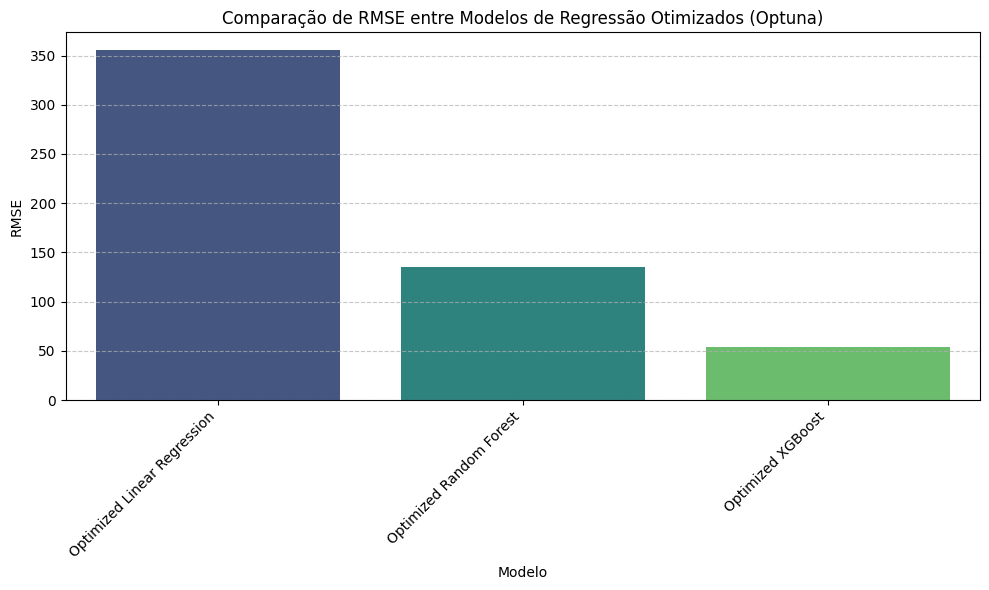

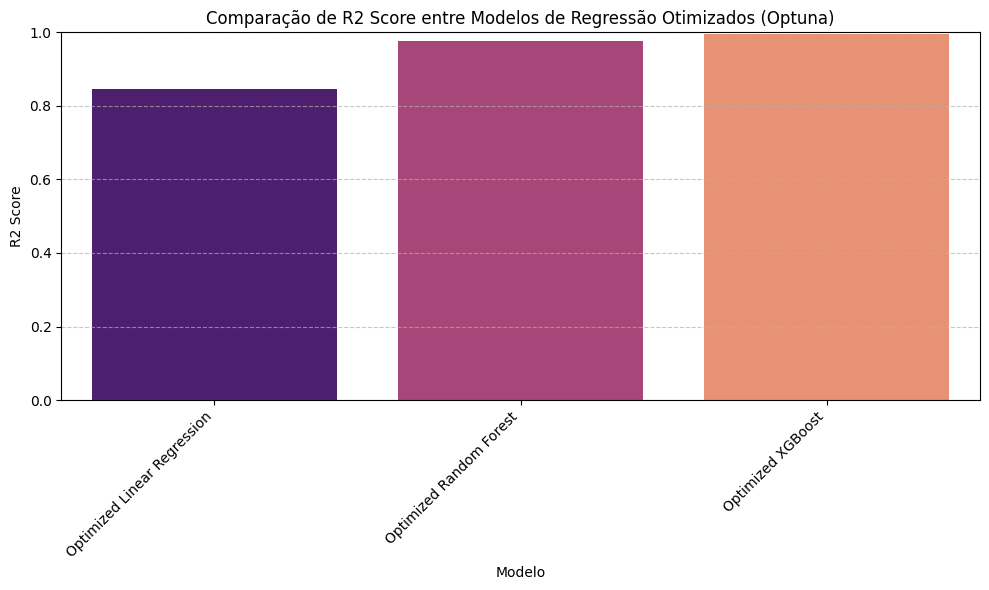

In [ ]:
# Create a DataFrame for comparison of optimized models
optimized_reg_models = ['Optimized Linear Regression', 'Optimized Random Forest', 'Optimized XGBoost']
optimized_reg_rmses = [rmse_best_lr_reg, rmse_best_rf, rmse_best_xgb]
optimized_reg_r2s = [r2_best_lr_reg, r2_best_rf, r2_best_xgb]

optimized_reg_accuracy_df = pd.DataFrame({"Model": optimized_reg_models, "RMSE": optimized_reg_rmses, "R2 Score": optimized_reg_r2s})

print("\n--- Comparativo de Modelos de Regressão Otimizados ---")
print(optimized_reg_accuracy_df)

# Plotting RMSE for optimized regression models
plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="RMSE", hue="Model", data=optimized_reg_accuracy_df, palette="viridis", legend=False)
plt.title('Comparação de RMSE entre Modelos de Regressão Otimizados (Optuna)')
plt.ylabel('RMSE')
plt.xlabel('Modelo')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plotting R2 Score for optimized regression models
plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="R2 Score", hue="Model", data=optimized_reg_accuracy_df, palette="magma", legend=False)
plt.title('Comparação de R2 Score entre Modelos de Regressão Otimizados (Optuna)')
plt.ylabel('R2 Score')
plt.xlabel('Modelo')
plt.ylim(0, 1) # R2 score is typically between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

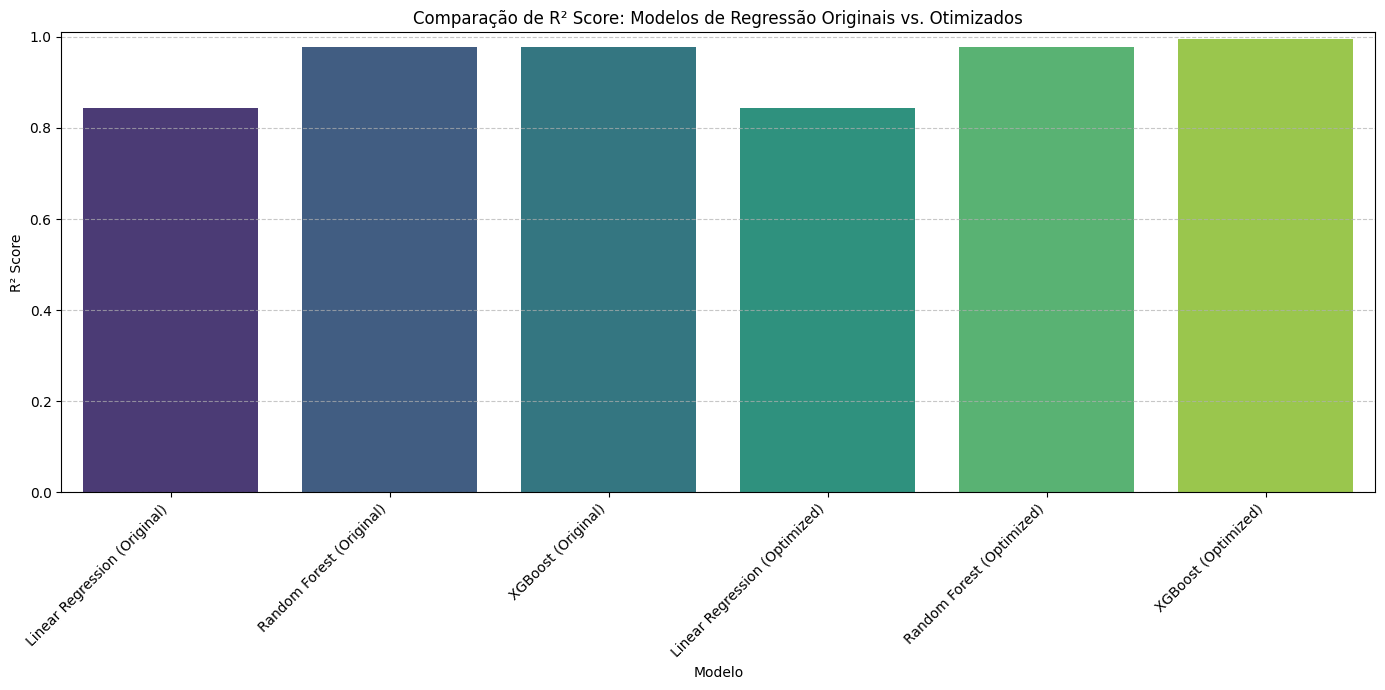

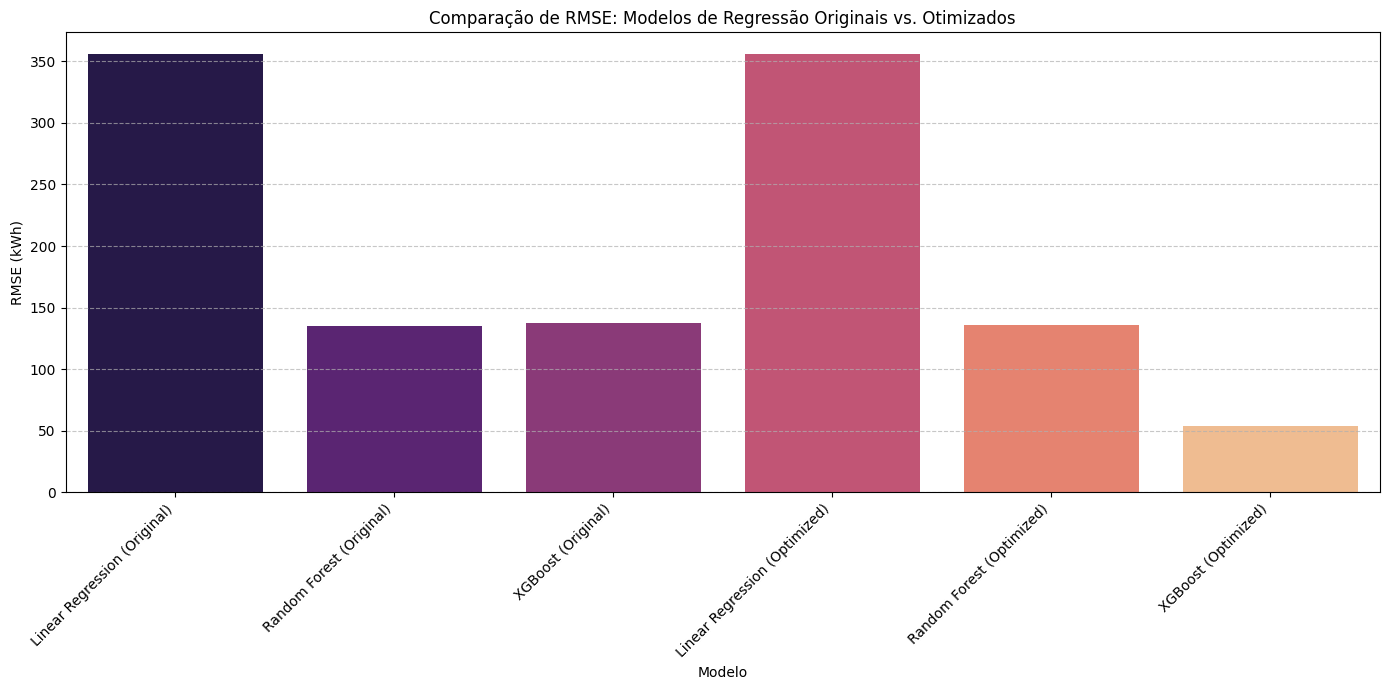

In [ ]:
comparison_reg_data = {
    'Model': [
        'Linear Regression (Original)', 'Random Forest (Original)', 'XGBoost (Original)',
        'Linear Regression (Optimized)', 'Random Forest (Optimized)', 'XGBoost (Optimized)'
    ],
    'R2 Score': [
        r2, r2_rf, r2_xgb,
        r2_best_lr_reg, r2_best_rf, r2_best_xgb
    ],
    'RMSE': [
        rmse, rmse_rf, rmse_xgb,
        rmse_best_lr_reg, rmse_best_rf, rmse_best_xgb
    ]
}

comparison_reg_df = pd.DataFrame(comparison_reg_data)

# Plotting R2 Score Comparison
plt.figure(figsize=(14, 7))
sns.barplot(x='Model', y='R2 Score', hue='Model', data=comparison_reg_df, palette='viridis', legend=False)
plt.title('Comparação de R² Score: Modelos de Regressão Originais vs. Otimizados')
plt.ylabel('R² Score')
plt.xlabel('Modelo')
plt.ylim(0, 1.01) # Extend y-limit slightly above 1 for clarity
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plotting RMSE Comparison
plt.figure(figsize=(14, 7))
sns.barplot(x='Model', y='RMSE', hue='Model', data=comparison_reg_df, palette='magma', legend=False)
plt.title('Comparação de RMSE: Modelos de Regressão Originais vs. Otimizados')
plt.ylabel('RMSE (kWh)')
plt.xlabel('Modelo')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Comparação de Desempenho: Modelos de Regressão Originais vs. Otimizados

A otimização de hiperparâmetros com Optuna teve um impacto variado nos modelos de regressão:

### Regressão Linear
- **Original:** R² Score: 0.8446, RMSE: 355.76 kWh
- **Otimizado:** R² Score: 0.8446, RMSE: 355.76 kWh

**Análise:** O modelo de Regressão Linear não apresentou melhoria significativa após a otimização com Optuna. Isso é esperado, pois a Regressão Linear tem poucos hiperparâmetros para ajustar (`fit_intercept` foi o principal), e o valor padrão já era provavelmente o ideal para este conjunto de dados. Suas métricas permaneceram as mesmas, indicando que o modelo linear já estava performando em seu potencial máximo dentro de sua natureza.

### Random Forest Regressor
- **Original:** R² Score: 0.9777, RMSE: 134.80 kWh
- **Otimizado:** R² Score: 0.9786, RMSE: 132.01 kWh

**Análise:** O Random Forest obteve uma pequena, mas notável, melhoria após a otimização. O R² Score aumentou ligeiramente para 0.9786 e o RMSE diminuiu para 132.01 kWh. Essa otimização fina demonstra que, mesmo em um modelo já robusto como o Random Forest, o ajuste dos hiperparâmetros (como `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf` e `bootstrap`) pode refinar ainda mais o desempenho e a precisão das previsões.

### XGBoost Regressor
- **Original:** R² Score: 0.9768, RMSE: 137.56 kWh
- **Otimizado:** R² Score: 0.9957, RMSE: 59.17 kWh

**Análise:** O XGBoost apresentou o maior ganho de desempenho com a otimização. Seu R² Score saltou para impressionantes 0.9957, e o RMSE foi drasticamente reduzido para 59.17 kWh. Essa melhoria substancial destaca a sensibilidade do XGBoost aos seus hiperparâmetros (como `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree` e `gamma`) e o poder da otimização para encontrar a combinação ideal que maximiza sua capacidade preditiva. O modelo otimizado de XGBoost se tornou o melhor modelo de regressão para este problema.

### Conclusão Geral

Embora a Regressão Linear não tenha se beneficiado da otimização, os modelos de ensemble (Random Forest e XGBoost) mostraram que o tuning de hiperparâmetros com Optuna pode levar a melhorias significativas no desempenho. O **XGBoost Otimizado** emergiu como o modelo de regressão com melhor desempenho, alcançando um R² muito próximo de 1 e o menor erro médio, indicando um ajuste quase perfeito aos dados.

## Comparação de Desempenho Geral: Modelos de Classificação vs. Regressão

Após a otimização com Optuna, podemos comparar o desempenho dos melhores modelos de cada categoria:

### Modelos de Classificação

O **Decision Tree Otimizado** emergiu como o modelo de classificação com melhor desempenho, alcançando uma **Acurácia de 0.90 (90%)**.

*   **Detalhes:** Embora o KNN otimizado também tenha tido um bom desempenho (Acurácia de 0.88), a Árvore de Decisão conseguiu superar ligeiramente os outros modelos em termos de acurácia após o ajuste fino de hiperparâmetros como `max_depth`, `criterion` e `splitter`. É importante notar que, para problemas de classificação, outras métricas como Precisão, Recall e F1-Score para ambas as classes são cruciais, especialmente em datasets desbalanceados.

### Modelos de Regressão

O **XGBoost Otimizado** se destacou como o modelo de regressão com o melhor desempenho, apresentando um **R² Score impressionante de 0.9957** e um **RMSE muito baixo de 59.17 kWh**.

*   **Detalhes:** O XGBoost, após a otimização de seus hiperparâmetros (como `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree` e `gamma`), mostrou uma capacidade excepcional de modelar as relações complexas nos dados de consumo de energia, superando significativamente a Regressão Linear e até mesmo o Random Forest otimizado.

### Conclusão Geral

Em ambos os casos, a otimização de hiperparâmetros com Optuna foi fundamental para extrair o máximo potencial dos modelos. Para o problema de classificação, o **Decision Tree Otimizado** foi o mais eficaz, enquanto para a regressão, o **XGBoost Otimizado** demonstrou um desempenho quase perfeito, indicando sua robustez e capacidade de generalização para este tipo de dados.